In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df= pd.read_excel("Forces Deployed.xlsx")

In [47]:
df

,data_year,ori,pub_agency_name,pub_agency_unit,state_abbr,division_name,region_name,county_name,agency_type_name,population_group_desc,...,male_officer_ct,male_cilvilian_ct,male_total_ct,female_officer_ct,female_cilvilian_ct,female_total_ct,officer_ct,civilian_ct,total_pe_ct,pe_ct_per_1000
0,2024,AK0010100,Anchorage,NaN,AK,Pacific,West,ANCHORAGE,City,"Cities from 250,000 thru 499,999",...,322,44,366,44,124,168,366,168,534,1.86
1,2024,AK0010200,Fairbanks,NaN,AK,Pacific,West,FAIRBANKS NORTH STAR,City,"Cities from 25,000 thru 49,999",...,24,2,26,4,6,10,28,8,36,1.14
2,2024,AK0010300,Juneau,NaN,AK,Pacific,West,JUNEAU,City,"Cities from 25,000 thru 49,999",...,38,13,51,3,21,24,41,34,75,2.37
3,2024,AK0010400,Ketchikan,NaN,AK,Pacific,West,KETCHIKAN GATEWAY,City,"Cities from 2,500 thru 9,999",...,20,0,20,2,10,12,22,10,32,3.98
4,2024,AK0010500,Kodiak,NaN,AK,Pacific,West,KODIAK ISLAND,City,"Cities from 2,500 thru 9,999",...,8,11,19,1,8,9,9,19,28,5.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73301,2020,WY0220100,Worland,NaN,WY,Mountain,West,WASHAKIE,City,"Cities from 2,500 thru 9,999",...,12,0,12,0,0,0,12,0,12,2.41
73302,2020,WY0230000,Weston,NaN,WY,Mountain,West,WESTON,County,"Non-MSA counties under 10,000",...,8,0,8,0,0,0,8,0,8,3.22
73303,2020,WY0230100,Newcastle,NaN,WY,Mountain,West,WESTON,City,"Cities from 2,500 thru 9,999",...,7,0,7,1,9,10,8,9,17,5.03
73304,2020,WYDI05000,Wind River Agency,NaN,WY,Mountain,West,NOT SPECIFIED,Tribal,"Cities under 2,500",...,14,0,14,4,4,8,18,4,22,NaN


In [50]:
df = df.dropna(subset=['pe_ct_per_1000'])
#drop state police / tribal since pe_ct_per_10000 isn't meaningful for them and their methods of policing are different than city police.
df = df[
    (df['pe_ct_per_1000'] < 50) &
    (df['agency_type_name'].isin(['City', 'County']))
]

In [ ]:
#The "Cities under 2,500" group has a max of 3,142 officers per 1,000 residents which is  Tavistock, NJ which 
#has a population of about 5 people and its own police department. Same story with Lakeside, CO (a tiny casino town), 
#Black Hawk, Vernon CA, etc. We removed these.

In [52]:
#Describing the variables
#Grouping by population
print(df['pe_ct_per_1000'].describe())
df.groupby('population_group_desc')['pe_ct_per_1000'].describe().round(2)

count    61397.000000
mean         3.011519
std          2.812041
min          0.000000
25%          1.710000
50%          2.410000
75%          3.460000
max         49.350000
Name: pe_ct_per_1000, dtype: float64


,count,mean,std,min,25%,50%,75%,max
population_group_desc,,,,,,,,
"Cities 1,000,000 or over",54.0,3.14,1.28,1.58,2.19,2.80,3.78,6.03
"Cities from 10,000 thru 24,999",8719.0,2.33,0.88,0.00,1.75,2.21,2.77,8.61
"Cities from 100,000 thru 249,999",1120.0,2.06,0.64,0.00,1.56,1.95,2.45,4.95
"Cities from 2,500 thru 9,999",16804.0,2.71,1.56,0.00,1.78,2.43,3.38,25.88
"Cities from 25,000 thru 49,999",4198.0,2.12,0.78,0.00,1.60,2.04,2.48,9.79
"Cities from 250,000 thru 499,999",251.0,2.38,0.86,0.92,1.80,2.14,2.54,5.56
"Cities from 50,000 thru 99,999",2255.0,2.04,0.72,0.00,1.55,1.94,2.38,7.08
"Cities from 500,000 thru 999,999",131.0,2.90,1.10,1.57,2.05,2.50,3.46,6.27
"Cities under 2,500",15121.0,3.60,4.28,0.00,1.42,2.60,4.31,49.35


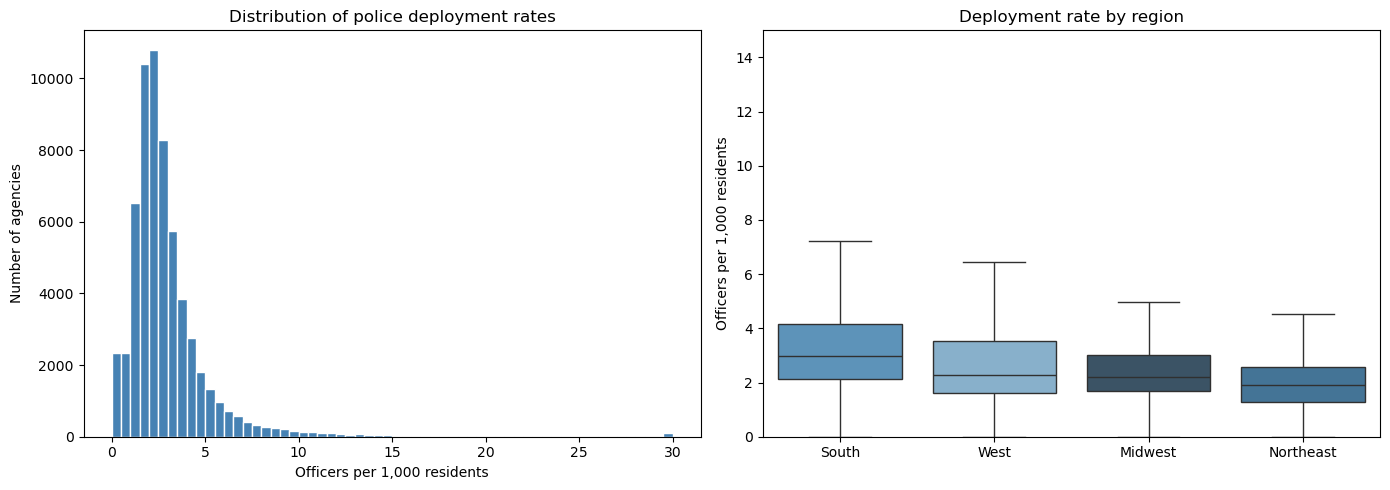

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histogram of overall distribution
axes[0].hist(df['pe_ct_per_1000'].clip(upper=30), bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Officers per 1,000 residents')
axes[0].set_ylabel('Number of agencies')
axes[0].set_title('Distribution of police deployment rates')

#boxplot by region
order = df.groupby('region_name')['pe_ct_per_1000'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='region_name', y='pe_ct_per_1000', order=order,
            showfliers=False, ax=axes[1], hue='region_name', legend=False,
            palette='Blues_d')
axes[1].set_ylim(0, 15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Officers per 1,000 residents')
axes[1].set_title('Deployment rate by region')
plt.tight_layout()
plt.show()

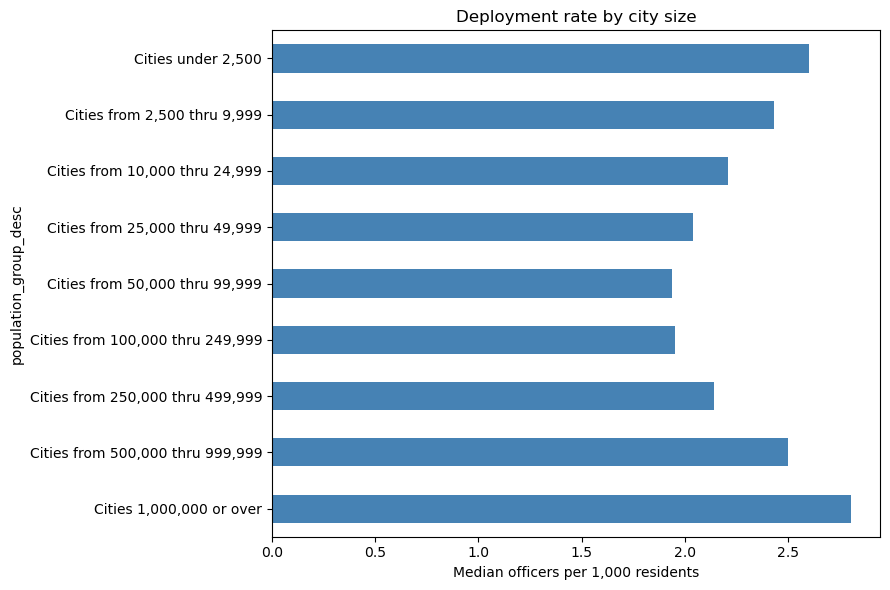

In [62]:
#Charts by city
size_order = [
    'Cities under 2,500', 'Cities from 2,500 thru 9,999',
    'Cities from 10,000 thru 24,999', 'Cities from 25,000 thru 49,999',
    'Cities from 50,000 thru 99,999', 'Cities from 100,000 thru 249,999',
    'Cities from 250,000 thru 499,999', 'Cities from 500,000 thru 999,999',
    'Cities 1,000,000 or over'
]

medians = (df[df['population_group_desc'].isin(size_order)]
           .groupby('population_group_desc')['pe_ct_per_1000']
           .median()
           .reindex(size_order))

medians.plot(kind='barh', figsize=(9, 6), color='steelblue')
plt.xlabel('Median officers per 1,000 residents')
plt.title('Deployment rate by city size')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [64]:
#Outliers
#The "Cities under 2,500" group has a max of 3,142 officers per 1,000 residents which is  Tavistock, NJ which 
#has a population of about 5 people and its own police department. Same story with Lakeside, CO (a tiny casino town), 
#Black Hawk, Vernon CA, etc. We removed these.
top = (df[['pub_agency_name', 'state_abbr', 'population_group_desc', 'pe_ct_per_1000']]
       .sort_values('pe_ct_per_1000', ascending=False)
       .head(25))
print(top.to_string(index=False))

    pub_agency_name state_abbr                population_group_desc  pe_ct_per_1000
           Morrison         CO                   Cities under 2,500           49.35
Ocean Beach Village         NY                   Cities under 2,500           48.19
             Medley         FL                   Cities under 2,500           48.13
               Webb         TX            MSA counties under 10,000           47.98
             Kenedy         TX        Non-MSA counties under 10,000           47.62
        Dewey Beach         DE                   Cities under 2,500           46.80
            Winkler         TX        Non-MSA counties under 10,000           46.76
           Linndale         OH                   Cities under 2,500           46.30
           McIntosh         AL                   Cities under 2,500           46.15
     Pawleys Island         SC                   Cities under 2,500           45.87
      Mission Woods         KS                   Cities under 2,500         

In [66]:
#By agency
type_med = (df.groupby('agency_type_name')['pe_ct_per_1000']
              .agg(['median', 'mean', 'count'])
              .sort_values('median', ascending=False)
              .round(2))
print(type_med)

                  median  mean  count
agency_type_name                     
County              2.98  3.74  12744
City                2.30  2.82  48653


In [ ]:
#Adding other data set
#We need to think of a way to connect these two.

In [84]:
crime_data = pd.read_csv("LA_Assault_Data_2020_Present.csv")

In [86]:
crime_data

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,Cross Street,LAT,LON,Assault Category
0,201516622,2020-10-21,2020-10-18,18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,ATOLL AV,N GAULT,34.1993,-118.4203,ADW / Aggravated Assault
1,201820230,2020-11-08,2020-11-08,07:30:00,18,Southeast,1844,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,626.0,108TH ST,AVALON AV,33.9383,-118.2652,Spousal Abuse (Simple)
2,201707577,2020-03-20,2020-03-20,13:20:00,17,Devonshire,1752,2,624,BATTERY - SIMPLE ASSAULT,...,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,624.0,20900 DEVONSHIRE ST,NaN,34.2572,-118.5885,Battery - Simple Assault
3,201608553,2020-04-28,2020-04-28,17:30:00,16,Foothill,1622,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,114.0,AIR PISTOL/REVOLVER/RIFLE/BB GUN,AA,Adult Arrest,230.0,10900 HADDON AV,NaN,34.2685,-118.4364,ADW / Aggravated Assault
4,202013248,2020-08-09,2020-08-09,22:50:00,20,Olympic,2069,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,626.0,1200 S WESTMORELAND AV,NaN,34.0495,-118.2891,Spousal Abuse (Simple)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196589,251104010,2025-01-03,2025-01-02,09:57:00,11,Northeast,1101,2,624,BATTERY - SIMPLE ASSAULT,...,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,624.0,2300 FERN DELL DR,NaN,34.1174,-118.3070,Battery - Simple Assault
196590,251104080,2025-01-29,2025-01-29,08:30:00,11,Northeast,1116,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,200.0,KNIFE WITH BLADE 6INCHES OR LESS,JA,Juv Arrest,230.0,800 N AVE 54,NaN,34.1152,-118.1991,ADW / Aggravated Assault
196591,251704039,2025-01-14,2025-01-14,16:00:00,17,Devonshire,1745,2,624,BATTERY - SIMPLE ASSAULT,...,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,624.0,10500 ZELZAH AV,NaN,34.2613,-118.5234,Battery - Simple Assault
196592,251704149,2025-02-28,2025-02-27,12:10:00,17,Devonshire,1771,2,624,BATTERY - SIMPLE ASSAULT,...,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,624.0,21000 PLUMMER ST,NaN,34.2428,-118.5913,Battery - Simple Assault
